      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 601.1902 - mae: 22.6355 - val_loss: 577.1507 - val_mae: 22.4919
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 554.0471 - mae: 21.6142 - val_loss: 500.7958 - val_mae: 20.7797
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 434.5288 - mae: 18.5821 - val_loss: 317.1860 - val_mae: 16.0109
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 212.6568 - mae: 12.0118 - val_loss: 88.2583 - val_mae: 7.2583
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 72.9583 - mae: 6.6695 - val_loss: 44.7069 - val_mae: 4.4545
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 41.0060 - mae: 4.8130 - val_loss: 40.4584 - val_mae: 4.1370
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 29.1033 - mae: 3.9470 - val_loss: 36.6061 - val_mae: 3.9598
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 24.9575 - mae: 3.6749 - val_loss: 36.1878 - val_mae: 3.9271
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━

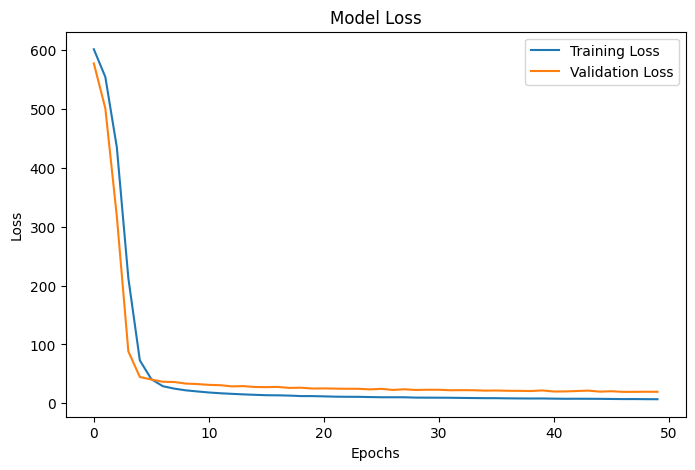

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


df = pd.read_csv(r"C:\Users\ACER\Downloads\1_boston_housing.csv")

# Display first 5 rows
print(df.head())

y = df["MEDV"]

# Features
X = df.drop("MEDV", axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])


model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)


y_pred = model.predict(X_test)



plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()